In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data=pd.read_csv("311.csv",low_memory=False)
data.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
0,32310363,12/31/2015 11:59:45 PM,01/01/2016 12:55:15 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)"
1,32309934,12/31/2015 11:59:44 PM,01/01/2016 01:26:57 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)"
2,32309159,12/31/2015 11:59:29 PM,01/01/2016 04:51:03 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)"
3,32305098,12/31/2015 11:57:46 PM,01/01/2016 07:43:13 AM,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)"
4,32306529,12/31/2015 11:56:58 PM,01/01/2016 03:24:42 AM,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)"


## print the columns of the DataFrame

In [2]:
data.columns

Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name',
       'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip',
       'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2',
       'Intersection Street 1', 'Intersection Street 2', 'Address Type',
       'City', 'Landmark', 'Facility Type', 'Status', 'Due Date',
       'Resolution Description', 'Resolution Action Updated Date',
       'Community Board', 'Borough', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Park Facility Name', 'Park Borough',
       'School Name', 'School Number', 'School Region', 'School Code',
       'School Phone Number', 'School Address', 'School City', 'School State',
       'School Zip', 'School Not Found', 'School or Citywide Complaint',
       'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location',
       'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp',
       'Bridge Highway Segment', 'Garage Lot Name', 'Ferry 

## identify the shape of the dataset

In [3]:
data.shape

(364558, 53)

## identify the variables with null values

In [4]:
data.isnull().sum()

Unique Key                             0
Created Date                           0
Closed Date                         2381
Agency                                 0
Agency Name                            0
Complaint Type                         0
Descriptor                          6501
Location Type                        133
Incident Zip                        2998
Incident Address                   51699
Street Name                        51699
Cross Street 1                     57188
Cross Street 2                     57805
Intersection Street 1             313438
Intersection Street 2             314046
Address Type                        3252
City                                2997
Landmark                          364183
Facility Type                       2389
Status                                 0
Due Date                               3
Resolution Description                 0
Resolution Action Updated Date      2402
Community Board                        0
Borough         

## Cha:2 Perform basic data exploratory analysis

### 2.1 Draw a frequeny plot to show the number of null values in each column of the DataFrame

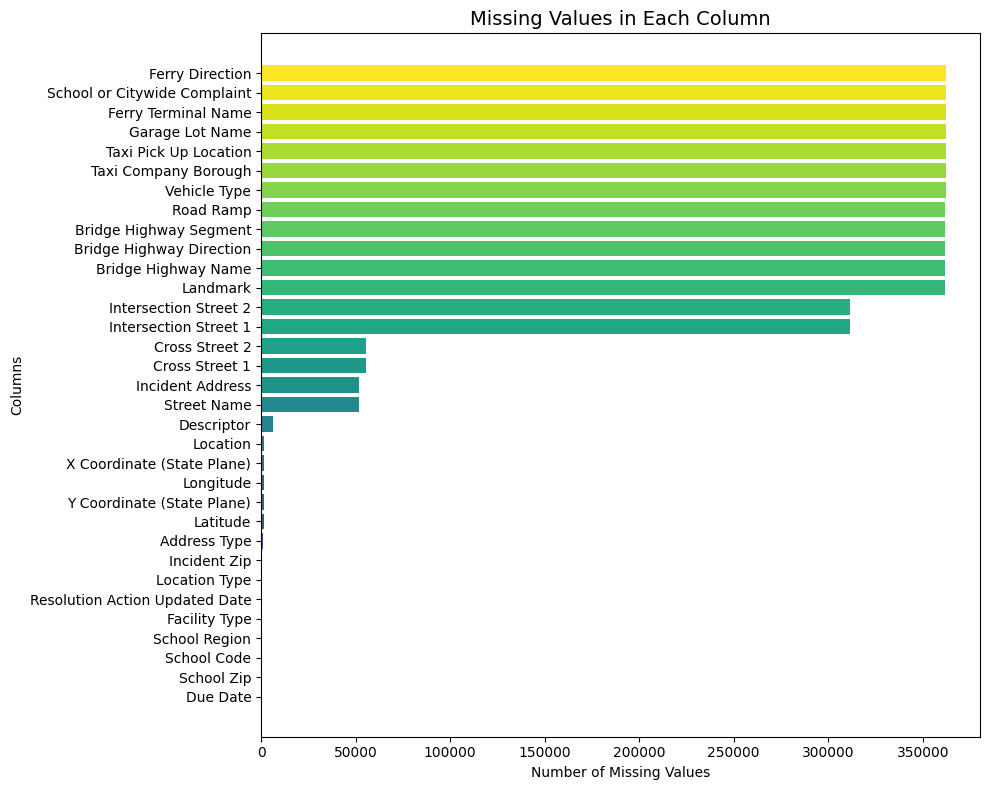

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate null values
null_values = data.isnull().sum()
null_values = null_values[null_values > 0]

# Sort values
null_values = null_values.sort_values()

# Create color gradient
colors = plt.cm.viridis(np.linspace(0, 1, len(null_values)))

# Plot
plt.figure(figsize=(10,8))
plt.barh(null_values.index, null_values.values, color=colors)

plt.title("Missing Values in Each Column", fontsize=14)
plt.xlabel("Number of Missing Values")
plt.ylabel("Columns")

plt.tight_layout()
plt.show()

### 2.2Missing value treatment

In [6]:
data=data[data['Closed Date'].notnull()]

(362177, 53)

### 2.3 Analyse the date column,and remove entries that have an incorrect timeline

In [7]:
data['Created Date']=pd.to_datetime(data['Created Date'],errors="coerce")
data['Closed Date']=pd.to_datetime(data['Closed Date'],errors="coerce")

C:\Users\DELL\AppData\Local\Temp\ipykernel_4444\131051512.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Created Date']=pd.to_datetime(data['Created Date'],errors="coerce")
C:\Users\DELL\AppData\Local\Temp\ipykernel_4444\131051512.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Closed Date']=pd.to_datetime(data['Closed Date'],errors="coerce")


### 2.3.1 Calculate the time elapsed in closed and creation date

In [8]:
data['Request_Closing_Time']=data['Closed Date']-data['Created Date']

### 2.3.2 Convert the calculated date to second to get a better representation

In [9]:
data['Request_Closing_Time']=data['Request_Closing_Time'].dt.total_seconds()

### 2.3.3 View the descriptive statistics for the newly created column

In [10]:
data['Request_Closing_Time'].describe()

count    3.621770e+05
mean     1.511330e+04
std      2.110255e+04
min      6.100000e+01
25%      4.533000e+03
50%      9.616000e+03
75%      1.887800e+04
max      2.134342e+06
Name: Request_Closing_Time, dtype: float64

### 2.3.4Check the number of null values in the complaint_Type and city columns

In [11]:
data[['Complaint Type','City']].isnull().sum()

Complaint Type      0
City              674
dtype: int64

### 2.3.5Impute the NA value with unknown city

In [13]:
data['City'].fillna("Unknown City",inplace=True)

### 2.3.6 Draw a frequency plot for the complaints in each city

<function matplotlib.pyplot.xticks(ticks: 'ArrayLike | None' = None, labels: 'Sequence[str] | None' = None, *, minor: 'bool' = False, **kwargs) -> 'tuple[list[Tick] | np.ndarray, list[Text]]'>

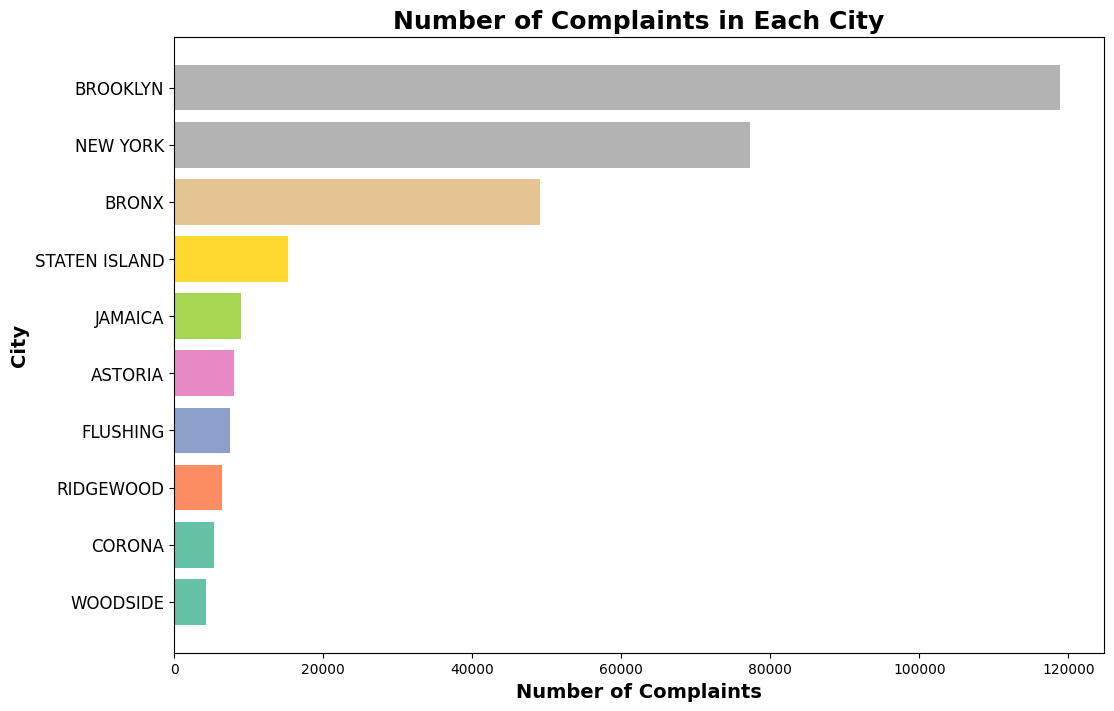

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Count complaints per city (Top 10 better look)
city_counts = data['City'].value_counts().head(10).sort_values()

# Color gradient
colors = plt.cm.Set2(np.linspace(0, 1, len(city_counts)))

plt.figure(figsize=(12,8))

bars = plt.barh(city_counts.index, city_counts.values, color=colors)

plt.title("Number of Complaints in Each City",
          fontsize=18, fontweight='bold')

plt.xlabel("Number of Complaints",
           fontsize=14, fontweight='bold')

plt.ylabel("City",
           fontsize=14, fontweight='bold')

# Increase font size of city names
plt.yticks(fontsize=12)
plt.xticks

### 2.3.7Create a scatter and hexbin plot of the concentration of complaints across Brooklyn

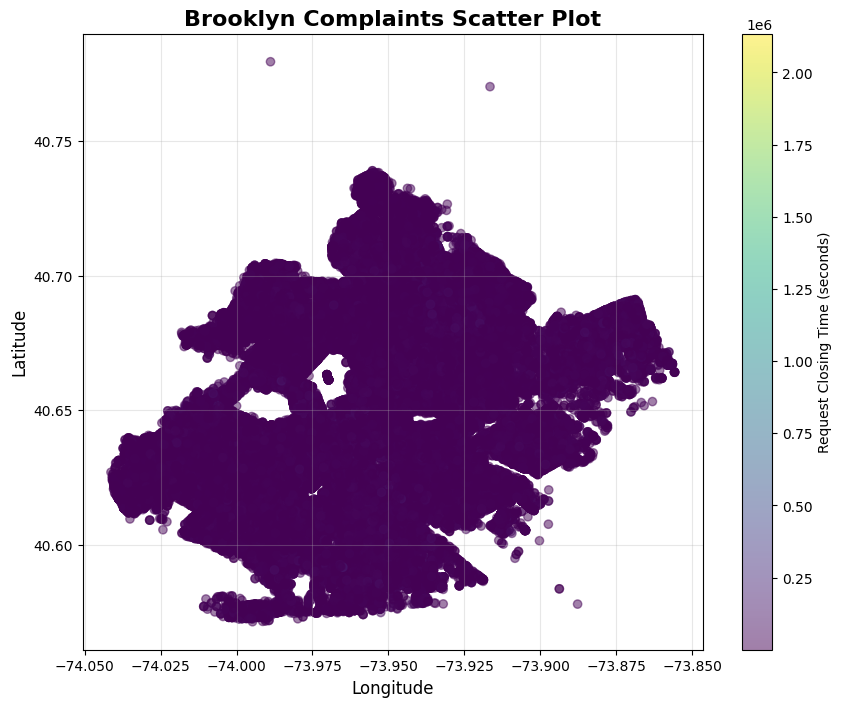

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.scatter(
    brooklyn['Longitude'],
    brooklyn['Latitude'],
    alpha=0.5,
    c=brooklyn['Request_Closing_Time'],
    cmap='viridis'
)

plt.colorbar(label='Request Closing Time (seconds)')

plt.title("Brooklyn Complaints Scatter Plot",
          fontsize=16, fontweight='bold')

plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)

plt.grid(alpha=0.3)
plt.show()

## 3.Find major types of complaints

### 3.1Plot a bar graph to show the types of complaints

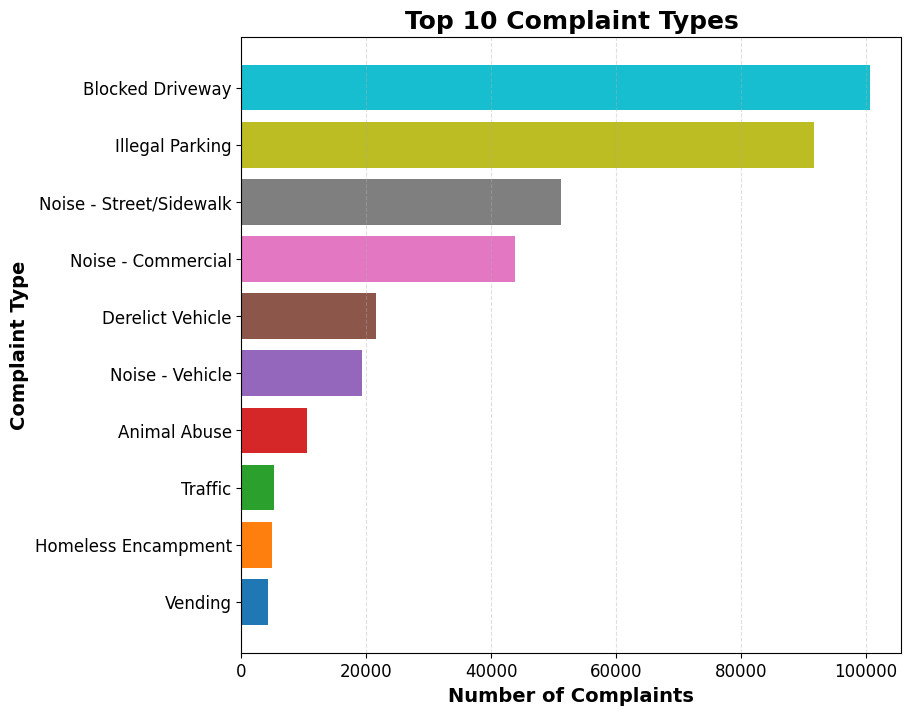

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Top 10 complaint types
complaint_counts = data['Complaint Type'].value_counts().head(10)
complaint_counts = complaint_counts.sort_values()

# Create color gradient
colors = plt.cm.tab10(np.linspace(0, 1, len(complaint_counts)))

plt.figure(figsize=(12,8))

plt.barh(complaint_counts.index, complaint_counts.values, color=colors)

plt.title("Top 10 Complaint Types",
          fontsize=18, fontweight='bold')

plt.xlabel("Number of Complaints",
           fontsize=14, fontweight='bold')

plt.ylabel("Complaint Type",
           fontsize=14, fontweight='bold')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.subplots_adjust(left=0.35)

plt.show()

### 3.2Check the frequency of various types of complaints for New York City

In [17]:
nyc = data[data['City'] == "NEW YORK"]
nyc['Complaint Type'].value_counts().head(10)

Complaint Type
Noise - Street/Sidewalk    22245
Noise - Commercial         18686
Illegal Parking            14549
Noise - Vehicle             6294
Homeless Encampment         3060
Blocked Driveway            2705
Vending                     2638
Animal Abuse                1941
Traffic                     1769
Noise - Park                1243
Name: count, dtype: int64

### 3.3Find the top 10 complaint types

In [18]:
top10 = data['Complaint Type'].value_counts().head(10)

### 3.4Display the various types of complaints in each city

In [19]:
pd.crosstab(data['City'], data['Complaint Type'])

Complaint Type,Agency Issues,Animal Abuse,Animal in a Park,Bike/Roller/Skate Chronic,Blocked Driveway,Derelict Vehicle,Disorderly Youth,Drinking,Graffiti,Homeless Encampment,...,Noise - House of Worship,Noise - Park,Noise - Street/Sidewalk,Noise - Vehicle,Panhandling,Posting Advertisement,Squeegee,Traffic,Urinating in Public,Vending
City,,,,,,,,,,,,,,,,,,,,,
ARVERNE,0,46,0,0,50,32,2,1,1,4,...,14,2,29,10,1,0,0,1,1,1
ASTORIA,0,170,0,16,3436,426,5,43,4,32,...,21,64,409,236,2,3,0,60,10,57
Astoria,0,0,0,0,159,14,0,0,0,0,...,0,0,145,0,0,0,0,0,0,0
BAYSIDE,0,53,0,0,514,231,2,1,3,2,...,3,4,17,24,0,0,0,9,0,2
BELLEROSE,0,15,0,1,138,120,2,1,0,1,...,1,1,13,11,1,1,0,9,1,0
BREEZY POINT,0,2,0,0,3,3,0,1,0,0,...,0,0,1,1,0,0,0,0,0,0
BRONX,0,1971,0,22,17062,2402,66,206,15,275,...,90,548,9144,3556,20,18,0,427,54,433
BROOKLYN,0,3191,0,124,36445,6257,79,291,60,948,...,389,1575,13982,5965,49,58,0,1258,155,575
CAMBRIA HEIGHTS,0,15,0,0,177,148,0,0,0,6,...,2,0,29,100,0,0,0,7,0,0


### 3.5Create a DataFrame, df_new, which contains cities as columns and complaint types in rows

In [20]:
df_new = pd.crosstab(data['Complaint Type'], data['City'])
df_new.head()

City,ARVERNE,ASTORIA,Astoria,BAYSIDE,BELLEROSE,BREEZY POINT,BRONX,BROOKLYN,CAMBRIA HEIGHTS,CENTRAL PARK,...,SOUTH OZONE PARK,SOUTH RICHMOND HILL,SPRINGFIELD GARDENS,STATEN ISLAND,SUNNYSIDE,Unknown City,WHITESTONE,WOODHAVEN,WOODSIDE,Woodside
Complaint Type,,,,,,,,,,,,,,,,,,,,,
Agency Issues,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,8,0,0,0,0
Animal Abuse,46,170,0,53,15,2,1971,3191,15,0,...,74,40,42,786,40,1,43,57,111,0
Animal in a Park,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bike/Roller/Skate Chronic,0,16,0,0,1,0,22,124,0,0,...,1,1,0,10,2,2,4,2,5,0
Blocked Driveway,50,3436,159,514,138,3,17062,36445,177,0,...,1202,1946,330,2845,278,86,279,1363,2038,27


## 4 Visualize the major types of complaints in each city

### 4.1Draw another chart that shows the types of complaints in each city in a single chart, where different colors show the different types of components

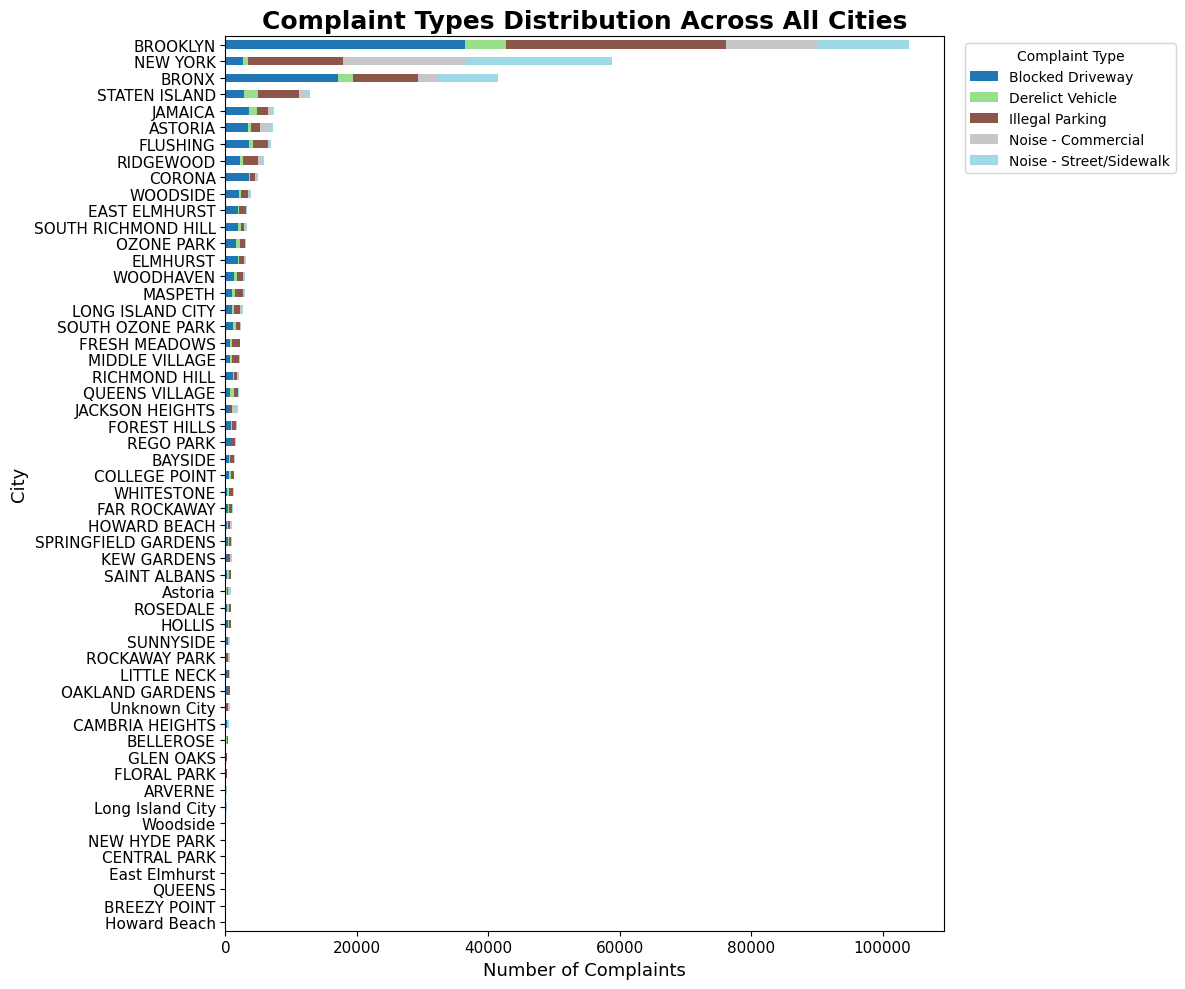

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

# Top 5 complaint types (colors clear दिसण्यासाठी)
top5 = data['Complaint Type'].value_counts().head(5).index

filtered = data[data['Complaint Type'].isin(top5)]

# Crosstab: City vs Complaint Type
df_chart = pd.crosstab(filtered['City'], filtered['Complaint Type'])

# Sort cities by total complaints (clean ordering)
df_chart = df_chart.loc[df_chart.sum(axis=1).sort_values().index]

# Plot
df_chart.plot(
    kind='barh',
    stacked=True,
    colormap='tab20',
    figsize=(12,10)
)

plt.title("Complaint Types Distribution Across All Cities",
          fontsize=18, fontweight='bold')

plt.xlabel("Number of Complaints", fontsize=13)
plt.ylabel("City", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.legend(title="Complaint Type", bbox_to_anchor=(1.02,1))

plt.tight_layout()
plt.show()

### 4.2Sort the complaint types based on the average Request_Closing_Timegrouping them for different locations

In [23]:
avg_time = data.groupby('Complaint Type')['Request_Closing_Time'].mean().sort_values()
avg_time.head()

Complaint Type
Posting Advertisement        7286.256259
Illegal Fireworks           10113.482558
Noise - Commercial          11085.760531
Noise - House of Worship    11391.087079
Noise - Park                12226.055515
Name: Request_Closing_Time, dtype: float64

## 5.See whether the average response time across different complaint types is similar (overall)

### 5.1Visualize the average of Request_Closing_Time

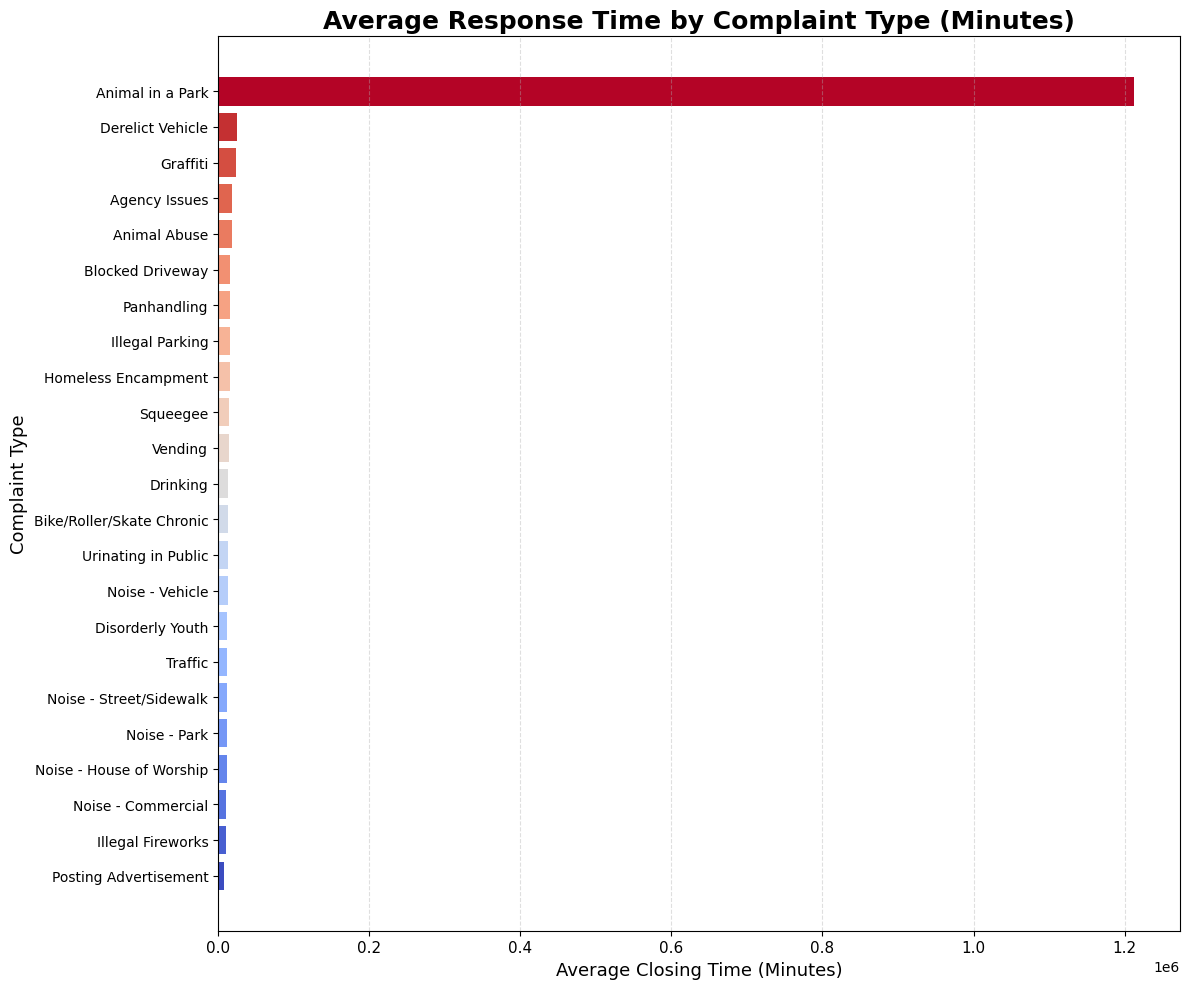

In [34]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,10))

colors = plt.cm.coolwarm(np.linspace(0,1,len(avg_time)))

plt.barh(avg_time.index, avg_time.values, color=colors)

plt.title("Average Response Time by Complaint Type (Minutes)",
          fontsize=18, fontweight='bold')

plt.xlabel("Average Closing Time (Minutes)", fontsize=13)
plt.ylabel("Complaint Type", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## 6.Identify the significant variables by performing statistical analysis using p-values


In [ ]:
!pip install scipy

In [ ]:
from scipy import stats

groups = [group["Request_Closing_Time"].values for name, group in data.groupby("Complaint Type")]

stats.f_oneway(*groups)

## 7.Perform a Kruskal-WallisH test

In [ ]:
from scipy import stats

groups = [group["Request_Closing_Time"].values 
          for name, group in data.groupby("Complaint Type")]

stat, p_value = stats.kruskal(*groups)

print("P-value:", p_value)

### 7.1Fail to reject H0: All sample distributions are equal

## 7.2Reject H0: One or more sample distributions are not equal